# NYC Street Tree Census 2015 Exploratory Data Analysis (EDA) and Data Cleaning

This notebook performs a comprehensive exploratory data analysis (EDA) on the **2015 NYC Street Tree Census** dataset.  
Full data science pipeline: from loading raw data to feature engineering.

## 1. Data Exploration and Preprocessing

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [43]:
warnings.filterwarnings('ignore')

In [2]:
tree_census = pd.read_csv('2015_Street_Tree_Census.csv')

In [3]:
print(f'Full dataset shape: {tree_census.shape}')

Full dataset shape: (165991, 45)


In [87]:
tree_census.head(10)

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,2015-08-27,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,...,"4,073,900",New York,40.723092,-73.844215,NaN,NaN,29.0,739,4052307.0,4.022210e+09
1,200540,315986,2015-09-03,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,...,"4,097,300",New York,40.794111,-73.818679,NaN,NaN,19.0,973,4101931.0,4.044750e+09
2,204026,218365,2015-09-05,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,"3,044,900",New York,40.717581,-73.936608,NaN,NaN,34.0,449,3338310.0,3.028870e+09
3,204337,217969,2015-09-05,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,"3,044,900",New York,40.713537,-73.934456,NaN,NaN,34.0,449,3338342.0,3.029250e+09
4,189565,223043,2015-08-30,21,0,OnCurb,Alive,Good,Tilia americana,American linden,...,"3,016,500",New York,40.666778,-73.975979,NaN,NaN,39.0,165,3025654.0,3.010850e+09
5,190422,106099,2015-08-30,11,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,"1,014,500",New York,40.770046,-73.984950,NaN,NaN,3.0,145,1076229.0,1.011310e+09
6,190426,106099,2015-08-30,11,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,"1,014,500",New York,40.770210,-73.985338,NaN,NaN,3.0,145,1076229.0,1.011310e+09
7,208649,103940,2015-09-07,9,0,OnCurb,Alive,Good,Tilia americana,American linden,...,"1,012,700",New York,40.762724,-73.987297,NaN,NaN,3.0,133,1086093.0,1.010410e+09
8,209610,407443,2015-09-08,6,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,"5,006,400",New York,40.596579,-74.076255,NaN,NaN,NaN,NaN,NaN,NaN
9,192755,207508,2015-08-31,21,0,OffsetFromCurb,Alive,Fair,Platanus x acerifolia,London planetree,...,"3,037,402",New York,40.586357,-73.969744,NaN,NaN,47.0,"37,402",3320727.0,3.072350e+09


In [5]:
# Columns of interest
COLS = [
    'tree_id', 'tree_dbh', 'stump_diam',
    'curb_loc', 'status', 'health', 'spc_latin',
    'steward', 'sidewalk', 'problems',
    'root_stone', 'root_grate', 'root_other',
    'trunk_wire', 'trnk_light', 'trnk_other',
    'brch_light', 'brch_shoe', 'brch_other'
]

In [6]:
df = tree_census[COLS].copy()
print(f'Subset shape: {df.shape}')

Subset shape: (165991, 19)


In [7]:
df.head()

,tree_id,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,steward,sidewalk,problems,root_stone,root_grate,root_other,trunk_wire,trnk_light,trnk_other,brch_light,brch_shoe,brch_other
0,180683,3,0,OnCurb,Alive,Fair,Acer rubrum,NaN,NoDamage,NaN,No,No,No,No,No,No,No,No,No
1,200540,21,0,OnCurb,Alive,Fair,Quercus palustris,NaN,Damage,Stones,Yes,No,No,No,No,No,No,No,No
2,204026,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,1or2,Damage,NaN,No,No,No,No,No,No,No,No,No
3,204337,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,NaN,Damage,Stones,Yes,No,No,No,No,No,No,No,No
4,189565,21,0,OnCurb,Alive,Good,Tilia americana,NaN,Damage,Stones,Yes,No,No,No,No,No,No,No,No


In [46]:
df.value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
tree_id,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,steward,sidewalk,problems,root_stone,root_grate,root_other,trunk_wire,trnk_light,trnk_other,brch_light,brch_shoe,brch_other,health_enc,tree_dbh_scaled,stump_diam_scaled,tree_dbh_norm,stump_diam_norm,total_problems,tree_dbh_cm,size_category,is_stump,has_problem,
386541,3,0,OnCurb,Alive,Fair,Quercus rubra,1or2,NoDamage,TrunkOther,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,-0.962796,-0.138259,0.007059,0.0,1.0,7.62,Sapling,0,1,1
1095,18,0,OnCurb,Alive,Good,Carpinus caroliniana,1or2,NoDamage,Stones,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.784446,-0.138259,0.042353,0.0,1.0,45.72,Medium,0,1,1
1507,2,0,OnCurb,Alive,Poor,Quercus macrocarpa,1or2,Damage,BranchOther,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-1.079279,-0.138259,0.004706,0.0,1.0,5.08,Sapling,0,1,1
2198,8,0,OnCurb,Alive,Good,Cornus alternifolia,1or2,Damage,"RootOther,TrunkOther",0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,-0.380382,-0.138259,0.018824,0.0,2.0,20.32,Small,0,1,1
2474,3,0,OnCurb,Alive,Poor,Amelanchier,1or2,NoDamage,TrunkOther,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.962796,-0.138259,0.007059,0.0,1.0,7.62,Sapling,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23076,3,0,OnCurb,Alive,Good,Amelanchier,3or4,Damage,Stones,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,-0.962796,-0.138259,0.007059,0.0,1.0,7.62,Sapling,0,1,1
21485,4,0,OnCurb,Alive,Good,Carpinus japonica,1or2,Damage,TrunkOther,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,-0.846313,-0.138259,0.009412,0.0,1.0,10.16,Small,0,1,1
20992,20,0,OnCurb,Alive,Good,Maackia amurensis,1or2,Damage,Stones,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.017412,-0.138259,0.047059,0.0,1.0,50.80,Medium,0,1,1


## 2. Descriptive Statistics

Summary statistics for all columns

tree_dbh and stump_diam are in INCHES (1 inch = 2.54 cm)

In [55]:
# df.describe()
df.describe(include='all')

,tree_id,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,steward,sidewalk,problems,...,health_enc,tree_dbh_scaled,stump_diam_scaled,tree_dbh_norm,stump_diam_norm,total_problems,tree_dbh_cm,size_category,is_stump,has_problem
count,165991.000000,165991.000000,165991.000000,165991,165991,157518,157519,46194,157519,62417,...,157518.000000,1.659910e+05,1.659910e+05,165991.000000,165991.000000,165991.000000,165991.000000,161162,165991.000000,165991.000000
unique,NaN,NaN,NaN,2,3,3,129,3,2,174,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN
top,NaN,NaN,NaN,OnCurb,Alive,Good,Platanus x acerifolia,1or2,NoDamage,Stones,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium,NaN,NaN
freq,NaN,NaN,NaN,160182,157519,122328,20553,38925,110388,24806,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69581,NaN,NaN
mean,268094.833931,11.265563,0.479183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.721778,-1.133506e-16,-1.892030e-17,0.026507,0.003423,0.517552,28.614529,NaN,0.028875,0.376026
std,59134.435377,8.584983,3.465847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.557185,1.000003e+00,1.000003e+00,0.020200,0.024756,0.779530,21.805858,NaN,0.167456,0.484388
min,7.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,-1.312244e+00,-1.382589e-01,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000
25%,225005.500000,5.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,-7.298304e-01,-1.382589e-01,0.011765,0.000000,0.000000,12.700000,NaN,0.000000,0.000000
50%,269734.000000,9.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,-2.638991e-01,-1.382589e-01,0.021176,0.000000,0.000000,22.860000,NaN,0.000000,0.000000
75%,315157.500000,16.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,5.514806e-01,-1.382589e-01,0.037647,0.000000,1.000000,40.640000,NaN,0.000000,1.000000


In [53]:
for col in df.columns:
    print(col, df[col].unique())

tree_id [180683 200540 204026 ... 364524 370542 365953]
tree_dbh [  3  21  10  11   9   6   8  13  22  30  12   2  14   4   5  33  19   7
   0  24  20  36  29  18  17  32  28  26  25  15  16  42  38  23  27   1
  37  39  35  31  34  41  44  43 425  50  51  40  72  45 122 169  46  47
  48 177  49  99 282  56  64  54  89  91 110  57  60  61  58  63  55 234
 120 255  52  71  76 228  88  53 204  74  62 109 217  80  75  68 102]
stump_diam [  0  16  15  30  10  25  17   5   1  20   3  21   4   7   6  23  35  12
  11   9  14   8  22  19  18  27  24  36  41  40  13  37  44  26  38  29
  48  34  52   2  55  31  50  72  28 100  43  32  53  70 140  39  33  45
  47  42  90  46  58  74  54  64  57  49  77 118  51 109  78  67  80 134
  76  79  69  56  60  61  96  65 131  71  89  59  63  66]
curb_loc ['OnCurb' 'OffsetFromCurb']
status ['Alive' 'Stump' 'Dead']
health ['Fair' 'Good' 'Poor' nan]
spc_latin ['Acer rubrum' 'Quercus palustris' 'Gleditsia triacanthos var. inermis'
 'Tilia americana' 'Platanu

In [56]:
# Data types
print('Column data types:')
print(df.dtypes)

Column data types:
tree_id                 int64
tree_dbh                int64
stump_diam              int64
curb_loc               object
status                 object
health                 object
spc_latin              object
steward                object
sidewalk               object
problems               object
root_stone            float64
root_grate            float64
root_other            float64
trunk_wire            float64
trnk_light            float64
trnk_other            float64
brch_light            float64
brch_shoe             float64
brch_other            float64
health_enc            float64
tree_dbh_scaled       float64
stump_diam_scaled     float64
tree_dbh_norm         float64
stump_diam_norm       float64
total_problems        float64
tree_dbh_cm           float64
size_category        category
is_stump                int64
has_problem             int64
dtype: object


## 3. Handling Missing Values

In [57]:
# Count NaNs per column
missing = df.isna().sum() #.sort_values(ascending=False)
missing

,0
tree_id,0
tree_dbh,0
stump_diam,0
curb_loc,0
status,0
health,8473
spc_latin,8472
steward,119797
sidewalk,8472
problems,103574


In [14]:
missing = df.isna().sum().sort_values(ascending=False)
# 2 dec values
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

            Missing Count  Missing %
health               8473       5.10
spc_latin            8472       5.10
steward            119797      72.17
sidewalk             8472       5.10
problems           103574      62.40
root_stone              1       0.00
root_grate              1       0.00
root_other              1       0.00
trunk_wire              1       0.00
trnk_light              1       0.00
trnk_other              1       0.00
brch_light              1       0.00
brch_shoe               1       0.00
brch_other              1       0.00


Are NaNs linked to Stumps and Dead trees?

Stumps and dead trees have no health/species info → expected NaNs

In [64]:
stumps    = df[df['status'] == 'Stump']
dead_trees = df[df['status'] == 'Dead']
alive      = df[df['status'] == 'Alive']

| is or

& is and

In [65]:
print(f"Stumps:     {len(stumps):>6}  | health NaN: {stumps['health'].isna().sum()}")
print(f"Dead trees: {len(dead_trees):>6}  | health NaN: {dead_trees['health'].isna().sum()}")
print(f"Alive:      {len(alive):>6}  | health NaN: {alive['health'].isna().sum()}")

Stumps:       4793  | health NaN: 4793
Dead trees:   3679  | health NaN: 3679
Alive:      157519  | health NaN: 1


## 4. Data Visualization Techniques

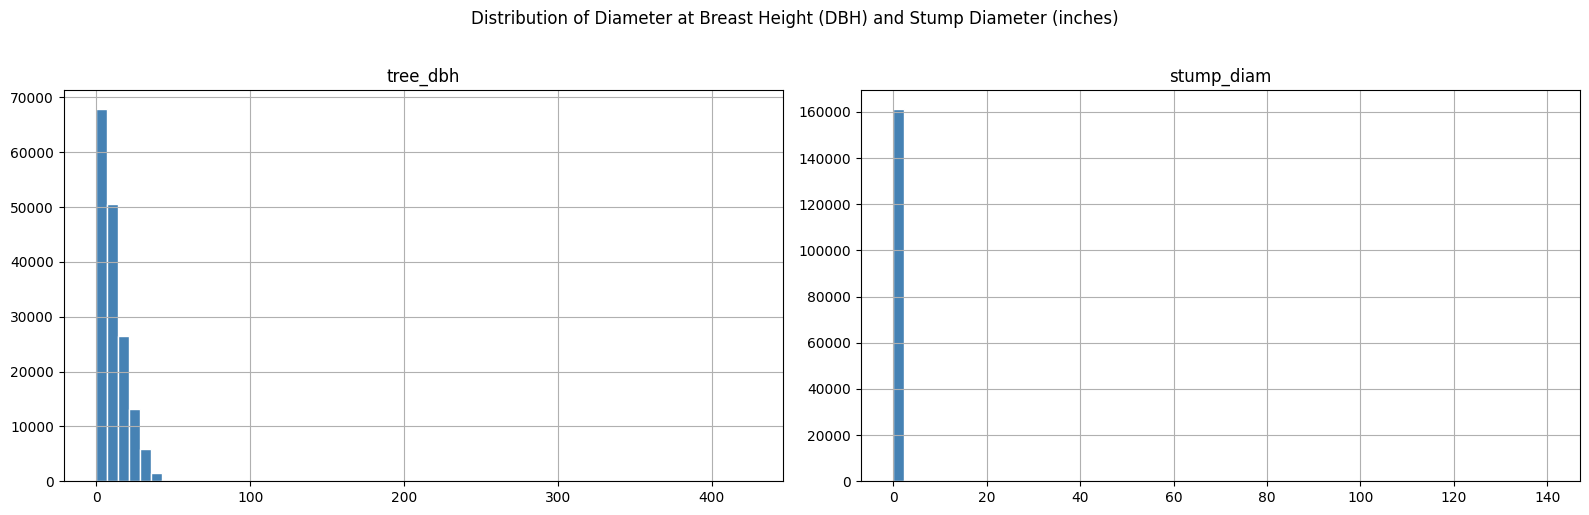

In [17]:
# Histograms for numeric features
df[['tree_dbh', 'stump_diam']].hist(bins=60, figsize=(16, 5), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Diameter at Breast Height (DBH) and Stump Diameter (inches)', y=1.02)
plt.tight_layout()
plt.show()

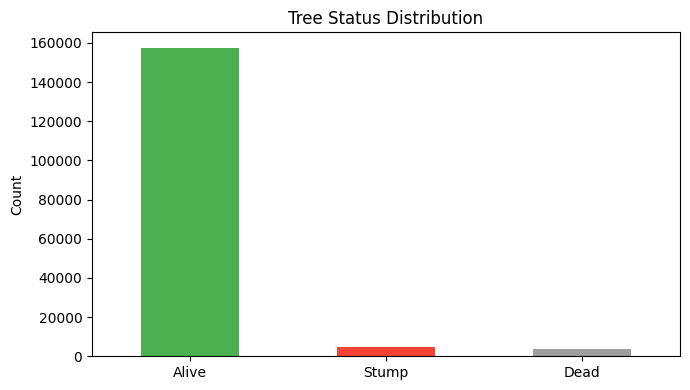

In [18]:
# Tree status distribution
fig, ax = plt.subplots(figsize=(7, 4))
df['status'].value_counts().plot(kind='bar', ax=ax, color=['#4caf50','#f44336','#9e9e9e'])
ax.set_title('Tree Status Distribution')
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

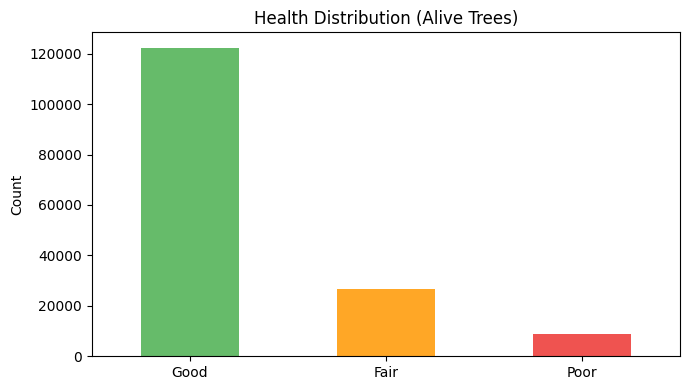

In [19]:
# Health distribution (alive trees only)
fig, ax = plt.subplots(figsize=(7, 4))
alive['health'].value_counts().plot(kind='bar', ax=ax, color=['#66bb6a','#ffa726','#ef5350'])
ax.set_title('Health Distribution (Alive Trees)')
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

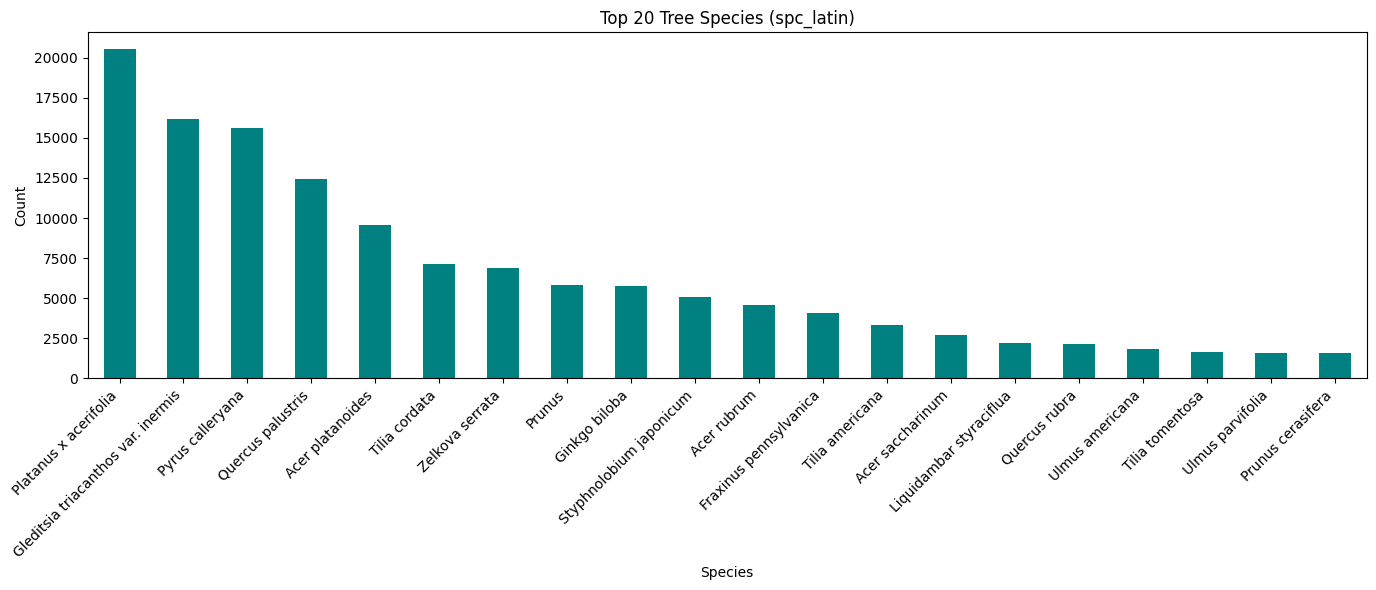

In [20]:
# Top 20 species by count
top20 = df['spc_latin'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(14, 6))
top20.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Top 20 Tree Species (spc_latin)')
ax.set_xlabel('Species')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Outlier Detection

Are very large trees real or data-entry errors?

Threshold: DBH > 50 inches (≈ 127 cm) is unusual but possible for mature oaks etc.

In [66]:
big_trees_dbh = df[df['tree_dbh'] > 50]
print(f'Trees with DBH > 50 inches: {len(big_trees_dbh)}')
big_trees_dbh[['tree_id', 'tree_dbh', 'spc_latin', 'status', 'health']].head(20)

Trees with DBH > 50 inches: 82


,tree_id,tree_dbh,spc_latin,status,health
2405,168583,425,Quercus bicolor,Alive,Good
3738,199546,51,Acer saccharinum,Alive,Good
4887,139665,72,Acer saccharinum,Alive,Good
6724,209349,122,Quercus palustris,Alive,Good
10083,215075,169,Gleditsia triacanthos var. inermis,Alive,Good
20379,215697,51,Acer rubrum,Alive,Good
25862,214532,177,Robinia pseudoacacia,Alive,Fair
27708,220146,51,Platanus x acerifolia,Alive,Good
29669,215564,99,Juniperus virginiana,Alive,Poor
29973,214534,282,Platanus x acerifolia,Alive,Good


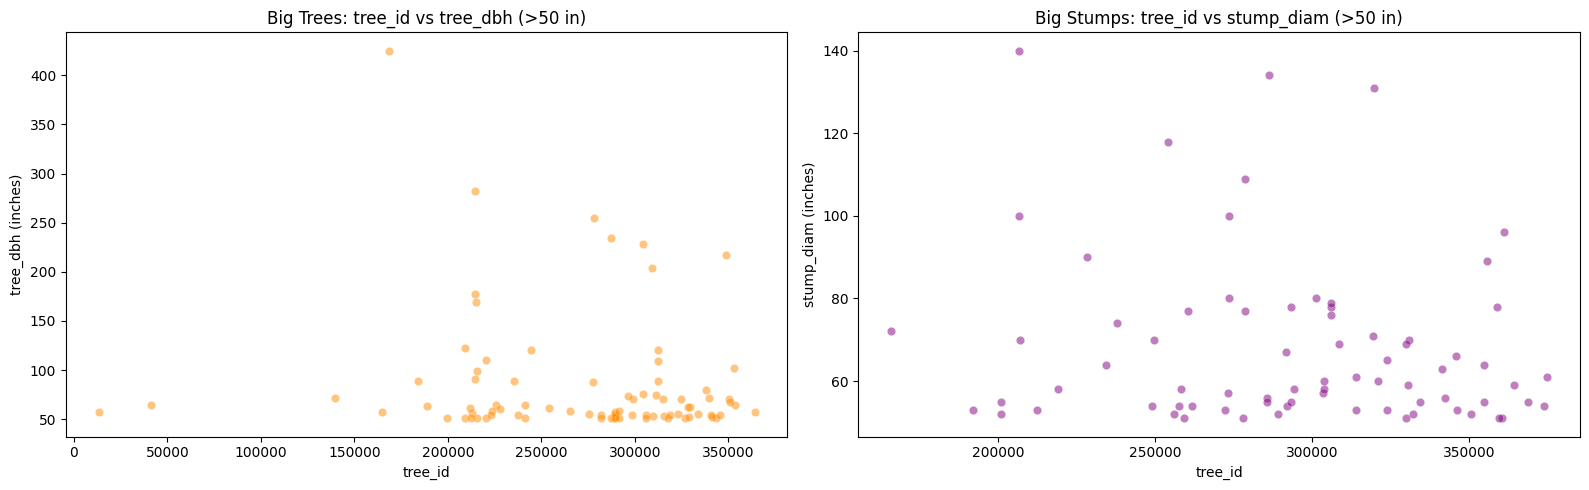

Stumps with stump_diam > 50 inches: 74


In [22]:
# Scatter plot: tree_id vs tree_dbh for big trees
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(big_trees_dbh['tree_id'], big_trees_dbh['tree_dbh'],
                alpha=0.5, color='darkorange', edgecolors='white', linewidth=0.3)
axes[0].set_title('Big Trees: tree_id vs tree_dbh (>50 in)')
axes[0].set_xlabel('tree_id')
axes[0].set_ylabel('tree_dbh (inches)')

big_stumps = df[df['stump_diam'] > 50]
axes[1].scatter(big_stumps['tree_id'], big_stumps['stump_diam'],
                alpha=0.5, color='purple', edgecolors='white', linewidth=0.3)
axes[1].set_title('Big Stumps: tree_id vs stump_diam (>50 in)')
axes[1].set_xlabel('tree_id')
axes[1].set_ylabel('stump_diam (inches)')

plt.tight_layout()
plt.show()

print(f'Stumps with stump_diam > 50 inches: {len(big_stumps)}')

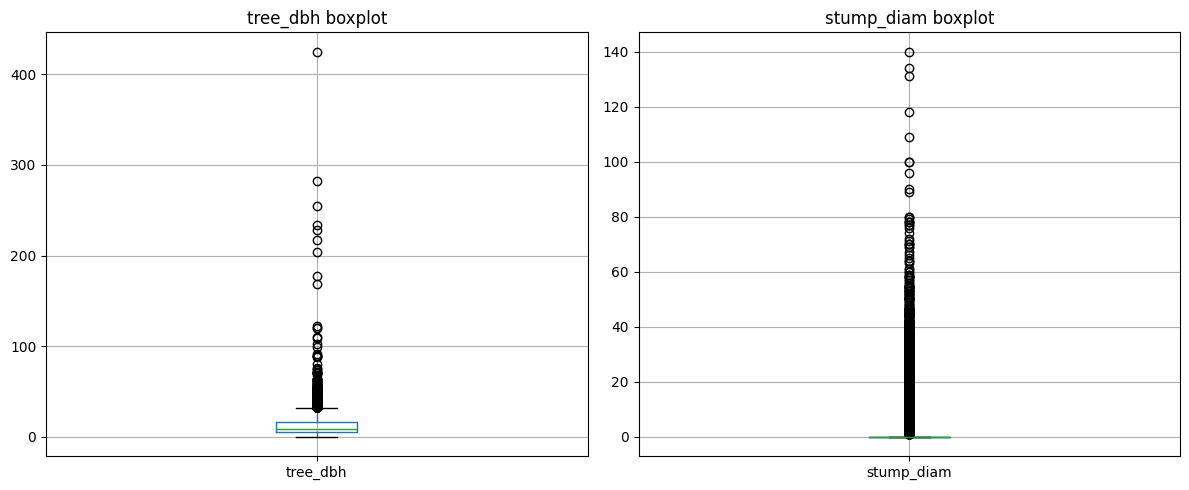

In [23]:
# Box plots for numeric columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(column='tree_dbh', ax=axes[0])
axes[0].set_title('tree_dbh boxplot')
df.boxplot(column='stump_diam', ax=axes[1])
axes[1].set_title('stump_diam boxplot')
plt.tight_layout()
plt.show()

In [24]:
# IQR-based outlier counts
for col in ['tree_dbh', 'stump_diam']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'{col}: IQR fence [{lo:.1f}, {hi:.1f}]  →  {n_out} outliers')

tree_dbh: IQR fence [-11.5, 32.5]  →  3603 outliers
stump_diam: IQR fence [0.0, 0.0]  →  4793 outliers


## 6. Correlation Analysis

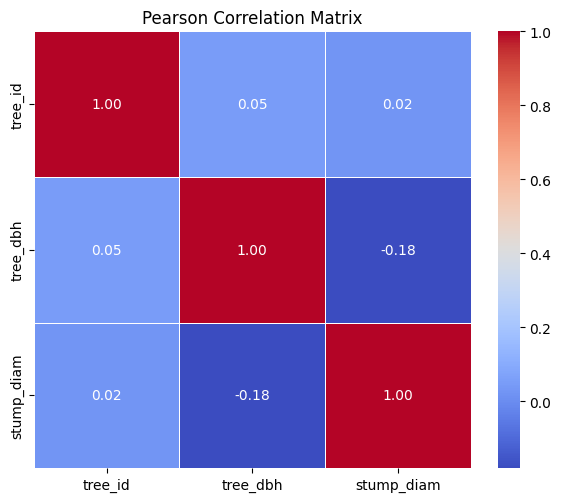

In [25]:
# Pearson correlation matrix for numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

## 7. Encoding Categorical Variables

In [26]:
# Ordinal encoding: health
health_map = {'Poor': 1,
              'Fair': 2,
              'Good': 3}
df['health_enc'] = df['health'].map(health_map)
print('health → health_enc mapping:')
print(df[['health', 'health_enc']].value_counts().sort_index())

health → health_enc mapping:
health  health_enc
Fair    2.0            26555
Good    3.0           122328
Poor    1.0             8635
Name: count, dtype: int64


In [27]:
# Binary encoding: problem columns (Yes/No → 1/0)
PROBLEM_COLS = [
    'root_stone', 'root_grate', 'root_other',
    'trunk_wire', 'trnk_light', 'trnk_other',
    'brch_light', 'brch_shoe', 'brch_other'
]

# Show raw value counts first
print('Raw value counts across problem columns:')
print(df[PROBLEM_COLS].apply(pd.Series.value_counts))

Raw value counts across problem columns:
     root_stone  root_grate  root_other  trunk_wire  trnk_light  trnk_other  \
No       128591      164658      157010      162555      165669      157008   
Yes       37399        1332        8980        3435         321        8982   

     brch_light  brch_shoe  brch_other  
No       148713     165882      157915  
Yes       17277        108        8075  


In [28]:
# Encode Yes/No → 1/0
yn_map = {'Yes': 1, 'No': 0}
df[PROBLEM_COLS] = df[PROBLEM_COLS].replace(yn_map)
df[PROBLEM_COLS].head()

,root_stone,root_grate,root_other,trunk_wire,trnk_light,trnk_other,brch_light,brch_shoe,brch_other
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 8. Data Scaling and Normalization

In [29]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [30]:
# Standard scaling (z-score norm)
scaler_std = StandardScaler()
df[['tree_dbh_scaled', 'stump_diam_scaled']] = scaler_std.fit_transform(
    df[['tree_dbh', 'stump_diam']]
)

In [31]:
# Min-Max scaling
scaler_mm = MinMaxScaler()
df[['tree_dbh_norm', 'stump_diam_norm']] = scaler_mm.fit_transform(
    df[['tree_dbh', 'stump_diam']]
)

In [32]:
print('Original vs scaled values:')
df[['tree_dbh', 'tree_dbh_scaled', 'tree_dbh_norm']].describe().round(3)

Original vs scaled values:


,tree_dbh,tree_dbh_scaled,tree_dbh_norm
count,165991.000,165991.000,165991.000
mean,11.266,-0.000,0.027
std,8.585,1.000,0.020
min,0.000,-1.312,0.000
25%,5.000,-0.730,0.012
50%,9.000,-0.264,0.021
75%,16.000,0.551,0.038
max,425.000,48.193,1.000


## 9. Feature Engineering

In [74]:
# Total number of problems per tree
df['total_problems'] = df[PROBLEM_COLS].sum(axis=1)
print('Problem count distribution:')
print(df['total_problems'].value_counts() )#.sort_index())

Problem count distribution:
total_problems
0.0    103574
1.0     44203
2.0     13769
3.0      3705
4.0       661
5.0        65
6.0        14
Name: count, dtype: int64


In [71]:
# Convert DBH from inches to centimeters
df['tree_dbh_cm'] = df['tree_dbh'] * 2.54

size_category ['Sapling', 'Medium', 'Small', 'Large', NaN]

Categories (4, object): ['Sapling' < 'Small' < 'Medium' < 'Large']

In [35]:
# Size category
bins   = [0, 3, 10, 30, np.inf]
labels = ['Sapling', 'Small', 'Medium', 'Large']
df['size_category'] = pd.cut(df['tree_dbh'], bins=bins, labels=labels)

In [36]:
print('Size category distribution:')
print(df['size_category'].value_counts().sort_index())

Size category distribution:
size_category
Sapling    22496
Small      63481
Medium     69581
Large       5604
Name: count, dtype: int64


Is the tree a stump?

In [80]:
df['is_stump'] = (df['status'] == 'Stump').astype(int)
df['is_stump']

,is_stump
0,0
1,0
2,0
3,0
4,0
...,...
165986,0
165987,0
165988,0
165989,0


Has any problem flag?

In [81]:
df['has_problem'] = (df['total_problems'] > 0).astype(int)
df['has_problem']

,has_problem
0,0
1,1
2,0
3,1
4,1
...,...
165986,0
165987,1
165988,0
165989,0


In [39]:
print('New binary feature counts:')
print(df[['is_stump', 'has_problem']].sum())

New binary feature counts:
is_stump        4793
has_problem    62417
dtype: int64


In [40]:
# Final engineered dataset overview
engineered_cols = [
    'tree_id', 'tree_dbh', 'tree_dbh_cm', 'tree_dbh_scaled', 'tree_dbh_norm',
    'size_category', 'health_enc', 'total_problems', 'has_problem', 'is_stump'
]

In [41]:
print(f'Dataframe shape: {df.shape}')
df[engineered_cols].head(10)

Final dataframe shape: (165991, 29)


,tree_id,tree_dbh,tree_dbh_cm,tree_dbh_scaled,tree_dbh_norm,size_category,health_enc,total_problems,has_problem,is_stump
0,180683,3,7.62,-0.962796,0.007059,Sapling,2.0,0.0,0,0
1,200540,21,53.34,1.133895,0.049412,Medium,2.0,1.0,1,0
2,204026,3,7.62,-0.962796,0.007059,Sapling,3.0,0.0,0,0
3,204337,10,25.40,-0.147416,0.023529,Small,3.0,1.0,1,0
4,189565,21,53.34,1.133895,0.049412,Medium,3.0,1.0,1,0
5,190422,11,27.94,-0.030933,0.025882,Medium,3.0,0.0,0,0
6,190426,11,27.94,-0.030933,0.025882,Medium,3.0,0.0,0,0
7,208649,9,22.86,-0.263899,0.021176,Small,3.0,1.0,1,0
8,209610,6,15.24,-0.613348,0.014118,Small,3.0,0.0,0,0
9,192755,21,53.34,1.133895,0.049412,Medium,2.0,0.0,0,0


# **FINAL**

Final Summary: All Engineered & Key Columns

In [86]:
final_cols = [
    # Identifikator
    'tree_id',

    # Originalne numeričke
    'tree_dbh',
    'stump_diam',

    # Konvertovane / skalirane
    'tree_dbh_cm',
    'tree_dbh_scaled',
    'tree_dbh_norm',
    'stump_diam_scaled',
    'stump_diam_norm',

    # Kategorijalne (originalne)
    'curb_loc',
    'status',
    'health',
    'spc_latin',
    'steward',
    'sidewalk',
    'problems',

    # Enkodovane kategorijske
    'health_enc',

    # Problem kolone (enkodovane Yes/No → 1/0)
    'root_stone', 'root_grate', 'root_other',
    'trunk_wire', 'trnk_light', 'trnk_other',
    'brch_light', 'brch_shoe', 'brch_other',

    # Feature engineering
    'total_problems',
    'has_problem',
    'size_category',
    'is_stump',
]

In [83]:
df_final = df[final_cols].copy()

In [84]:
print("=" * 60)
print(f"  FINALNI DATASET")
print("=" * 60)
print(f"  Redova:   {df_final.shape[0]:,}")
print(f"  Kolona:   {df_final.shape[1]}")
print("=" * 60)

print("\n── Tipovi kolona ─────────────────────────────────────────")
print(df_final.dtypes)

print("\n── Prvih 5 redova ────────────────────────────────────────")
df_final.head()

  FINALNI DATASET
  Redova:   165,991
  Kolona:   29

── Tipovi kolona ─────────────────────────────────────────
tree_id                 int64
tree_dbh                int64
stump_diam              int64
tree_dbh_cm           float64
tree_dbh_scaled       float64
tree_dbh_norm         float64
stump_diam_scaled     float64
stump_diam_norm       float64
curb_loc               object
status                 object
health                 object
spc_latin              object
steward                object
sidewalk               object
problems               object
health_enc            float64
root_stone            float64
root_grate            float64
root_other            float64
trunk_wire            float64
trnk_light            float64
trnk_other            float64
brch_light            float64
brch_shoe             float64
brch_other            float64
total_problems        float64
has_problem             int64
size_category        category
is_stump                int64
dtype: object

──

,tree_id,tree_dbh,stump_diam,tree_dbh_cm,tree_dbh_scaled,tree_dbh_norm,stump_diam_scaled,stump_diam_norm,curb_loc,status,...,trunk_wire,trnk_light,trnk_other,brch_light,brch_shoe,brch_other,total_problems,has_problem,size_category,is_stump
0,180683,3,0,7.62,-0.962796,0.007059,-0.138259,0.0,OnCurb,Alive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Sapling,0
1,200540,21,0,53.34,1.133895,0.049412,-0.138259,0.0,OnCurb,Alive,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,Medium,0
2,204026,3,0,7.62,-0.962796,0.007059,-0.138259,0.0,OnCurb,Alive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Sapling,0
3,204337,10,0,25.40,-0.147416,0.023529,-0.138259,0.0,OnCurb,Alive,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,Small,0
4,189565,21,0,53.34,1.133895,0.049412,-0.138259,0.0,OnCurb,Alive,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,Medium,0


**func used:**

pd.read_csv('...')

.copy()

df.shape

df.head()

df.dtypes

df.describe(include='all')

df.value_counts()

df.unique()

df.isna().sum().sort_values(ascending=False)

df.isna().T

df[df['col'] == 'value']

df['col'].quantile([0.25, 0.75])

df['col'].map({...})

df['col'].replace({...})

df[cols].sum(axis=1)

df[cols].apply(pd.Series.value_counts)

pd.cut(df['col'], bins=[...], labels=[...])

df.select_dtypes(include=[np.number])

df.corr()

df.boxplot(column='...')

df.hist(bins=60, figsize=(...))

.plot(kind='bar')

.plot(kind='scatter', x='...', y='...')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

sns.heatmap(df.isna().T, cbar=False)

StandardScaler().fit_transform(...)

MinMaxScaler().fit_transform(...)

.astype(int)

.sort_index()

.round(2)